## Image Classifying Project - Dogs and Cats


In [1]:

import os
import numpy as np
import matplotlib.pyplot as plt
from tensorflow import keras
from keras.preprocessing import image



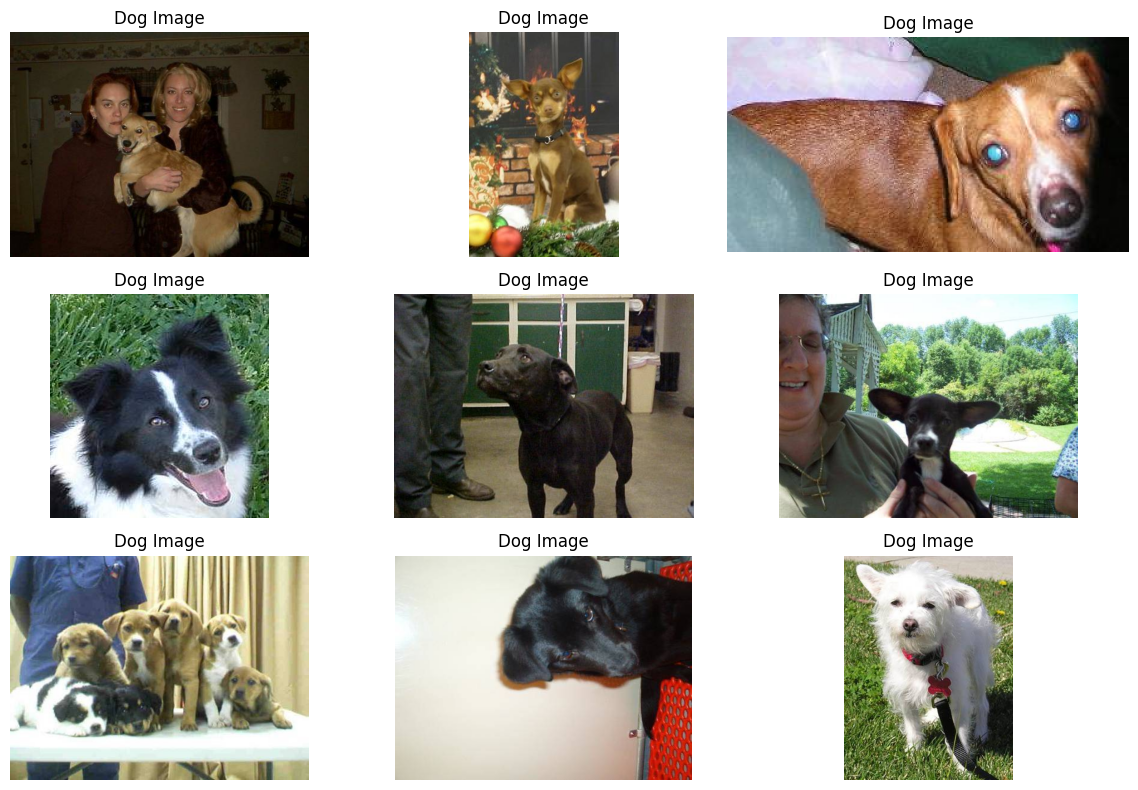

In [2]:
# Path to the directory containing your image data
data_dir = "../data/raw"

# Get a list of all dog image file names
dog_subfolder = os.path.join(data_dir, "dog")

# Get a list of all dog image file names
dog_image_files = os.listdir(dog_subfolder)

# Load the first nine dog images
dog_images = []
for i in range(9):
    img_path = os.path.join(dog_subfolder, dog_image_files[i])
    img = image.load_img(img_path)  # Adjust target_size as needed
    img_array = image.img_to_array(img)
    img_array /= 255.0  # Normalize pixel values to [0, 1]
    dog_images.append(img_array)

# Create a single figure to display all nine images
plt.figure(figsize=(12, 8))

for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(dog_images[i])
    plt.title('Dog Image')
    plt.axis('off')

# Adjust Layout
plt.tight_layout()

# Show the pictures
plt.show()

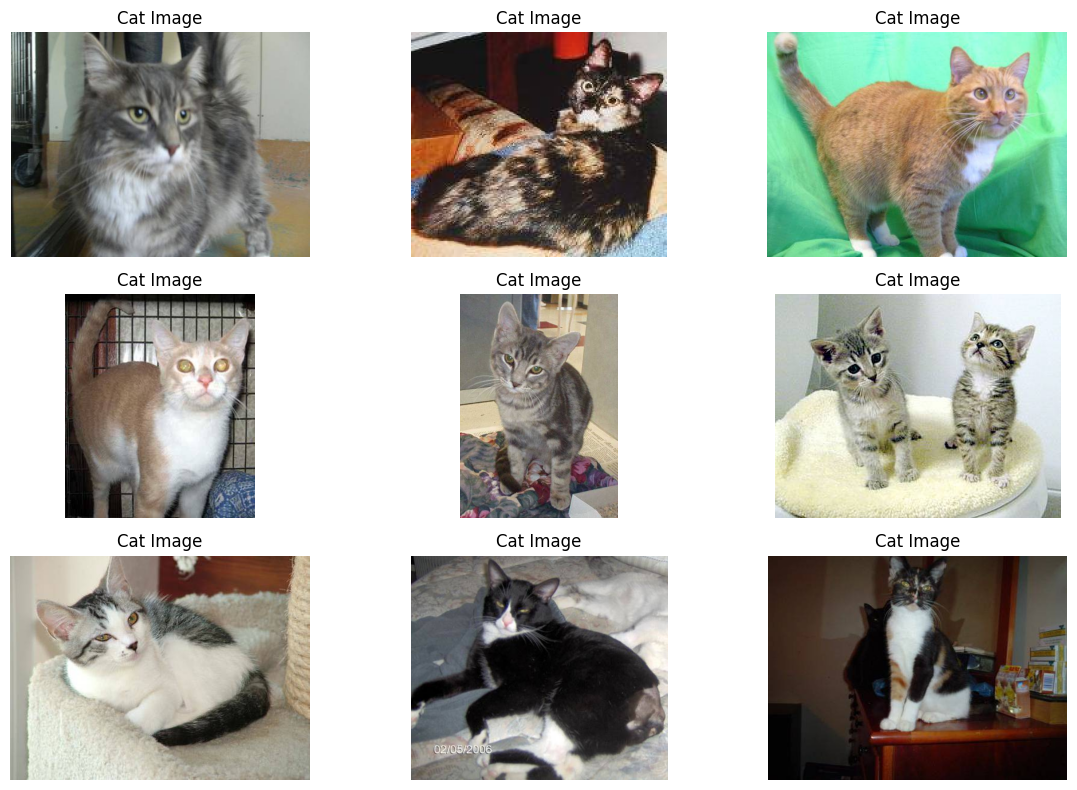

In [3]:

# Path to the directory containing your image data
data_dir = "../data/raw"

# Get a list of all cat image file names
cats_subfolder = os.path.join(data_dir, "cat")

# Get a list of all Cat image file names
cats_image_files = os.listdir(cats_subfolder)

# Load the first nine cat images
cats_images = []
for i in range(min(9, len(cats_image_files))):  # Limit to available cat images
    img_path = os.path.join(cats_subfolder, cats_image_files[i])
    img = image.load_img(img_path)
    img_array = image.img_to_array(img)
    img_array /= 255.0
    cats_images.append(img_array)

# Create a single figure to display all cat images
plt.figure(figsize=(12, 8))

for i in range(len(cats_images)):
    plt.subplot(3, 3, i + 1)
    plt.imshow(cats_images[i])
    plt.title('Cat Image')
    plt.axis('off')

# Adjust Layout
plt.tight_layout()

# Show the pictures
plt.show()

In [4]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Define a few rules for DataGen
train_dir = "../data/raw"
image_size = (224, 224)
batch_size = 8

datagen = ImageDataGenerator(
    rescale=1.0 / 255,
    validation_split=0.2
 )

# Train Data Generation
train_data = datagen.flow_from_directory(
    train_dir,
    target_size=image_size,
    batch_size=batch_size,
    classes=["dog", "cat"],
    class_mode="categorical",
    subset="training",
    shuffle=True
 )

# Validation Data Generation
test_data = datagen.flow_from_directory(
    train_dir,
    target_size=image_size,
    batch_size=batch_size,
    classes=["dog", "cat"],
    class_mode="categorical",
    subset="validation",
    shuffle=False
 )

Found 16 images belonging to 2 classes.
Found 2 images belonging to 2 classes.


In [5]:
# Move the Data Through the Neural Network
from keras.models import Sequential
from keras.layers import Dense, Conv2D, MaxPool2D , Flatten

model = Sequential()
model.add(Conv2D(input_shape = (224,224,3), filters = 64, kernel_size = (3,3), padding = "same", activation = "relu"))
model.add(Conv2D(filters = 64,kernel_size = (3,3),padding = "same", activation = "relu"))
model.add(MaxPool2D(pool_size = (2,2),strides = (2,2)))
model.add(Conv2D(filters = 128, kernel_size = (3,3), padding = "same", activation = "relu"))
model.add(Conv2D(filters = 128, kernel_size = (3,3), padding = "same", activation = "relu"))
model.add(MaxPool2D(pool_size = (2,2),strides = (2,2)))
model.add(Conv2D(filters = 256, kernel_size = (3,3), padding = "same", activation = "relu"))
model.add(Conv2D(filters = 256, kernel_size = (3,3), padding = "same", activation = "relu"))
model.add(Conv2D(filters = 256, kernel_size = (3,3), padding = "same", activation = "relu"))
model.add(MaxPool2D(pool_size = (2,2),strides = (2,2)))
model.add(Conv2D(filters = 512, kernel_size = (3,3), padding = "same", activation = "relu"))
model.add(Conv2D(filters = 512, kernel_size = (3,3), padding = "same", activation = "relu"))
model.add(Conv2D(filters = 512, kernel_size = (3,3), padding = "same", activation = "relu"))
model.add(MaxPool2D(pool_size = (2,2),strides = (2,2)))
model.add(Conv2D(filters = 512, kernel_size = (3,3), padding = "same", activation = "relu"))
model.add(Conv2D(filters = 512, kernel_size = (3,3), padding = "same", activation = "relu"))
model.add(Conv2D(filters = 512, kernel_size = (3,3), padding = "same", activation = "relu"))
model.add(MaxPool2D(pool_size = (2,2),strides = (2,2)))

# Move the Data through the Dense Layers
model.add(Flatten())
model.add(Dense(units = 4096,activation = "relu"))
model.add(Dense(units = 4096,activation = "relu"))
model.add(Dense(units = 2, activation = "softmax"))



c:\Users\Owner\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [6]:
# Compile the Model using Adam 
from keras.optimizers import Adam

# Compile the Model before Training
model.compile(loss = keras.losses.categorical_crossentropy, optimizer = Adam(learning_rate = 0.001), metrics = ["accuracy"])

In [7]:
# Train the Model
model.fit(train_data, epochs = 1)


2/2 ━━━━━━━━━━━━━━━━━━━━ 6s 2s/step - accuracy: 0.5000 - loss: 1.1679


In [8]:
from keras.callbacks import ModelCheckpoint, EarlyStopping

checkpoint = ModelCheckpoint("../models/vgg16_1.keras", monitor = "val_accuracy", verbose = 1, save_best_only = True, mode = "max")
early = EarlyStopping(monitor = "val_accuracy", patience = 3, verbose = 1, mode = "max", restore_best_weights = True)
hist = model.fit(train_data, validation_data = test_data, epochs = 3, callbacks = [checkpoint, early])

Epoch 1/3
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.3750 - loss: 0.8205
Epoch 1: val_accuracy improved from None to 0.50000, saving model to ../models/vgg16_1.keras

Epoch 1: finished saving model to ../models/vgg16_1.keras
2/2 ━━━━━━━━━━━━━━━━━━━━ 8s 6s/step - accuracy: 0.5000 - loss: 0.7646 - val_accuracy: 0.5000 - val_loss: 0.7297
Epoch 2/3
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.4375 - loss: 0.7803
Epoch 2: val_accuracy did not improve from 0.50000
2/2 ━━━━━━━━━━━━━━━━━━━━ 4s 2s/step - accuracy: 0.5000 - loss: 0.7447 - val_accuracy: 0.5000 - val_loss: 0.6950
Epoch 3/3
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5000 - loss: 0.6947
Epoch 3: val_accuracy did not improve from 0.50000
2/2 ━━━━━━━━━━━━━━━━━━━━ 4s 2s/step - accuracy: 0.5000 - loss: 0.6943 - val_accuracy: 0.5000 - val_loss: 0.6932
Restoring model weights from the end of the best epoch: 1.


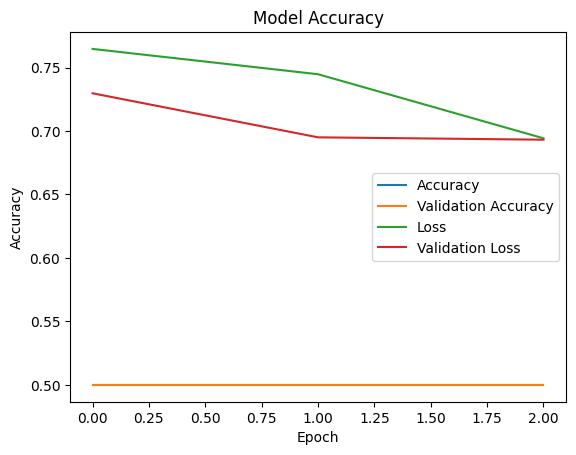

In [9]:
# Plot the Results
plt.plot(hist.history["accuracy"])
plt.plot(hist.history["val_accuracy"])
plt.plot(hist.history["loss"])
plt.plot(hist.history["val_loss"])

# Configure the Plot Layout
plt.title("Model Accuracy")
plt.ylabel("Accuracy")
plt.xlabel("Epoch")
plt.legend(["Accuracy", "Validation Accuracy", "Loss", "Validation Loss"])

# Plot
plt.show()



1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 314ms/step
dog


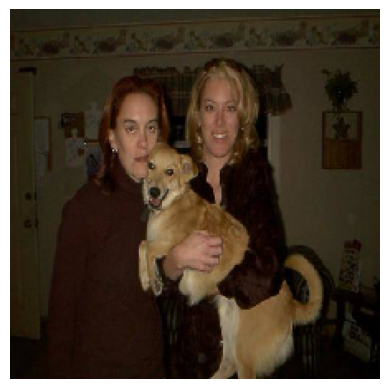

In [10]:
import os
from keras.models import load_model
from keras.utils import load_img, img_to_array

# Pick an existing sample image from the dataset
sample_dir = "../data/raw/dog"
sample_file = sorted(os.listdir(sample_dir))[0]
sample_path = os.path.join(sample_dir, sample_file)

img = load_img(sample_path, target_size=(224, 224))
img = img_to_array(img) / 255.0
plt.imshow(img.astype("float32"))
plt.axis("off")
img = np.expand_dims(img, axis=0)

saved_model = load_model("../models/vgg16_1.keras")
output = saved_model.predict(img)
if output[0][0] > output[0][1]:
    print("cat")
else:
    print("dog")